<a href="https://colab.research.google.com/github/RagaSandhiya05/heart-disease-prediction-using-ml/blob/main/HEART_DISEASE_PREDICTION_USING_MACHINE_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing the Dependencies**

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input , Dense , Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay , accuracy_score , precision_score , recall_score , f1_score

**Data Collection and Processing**

In [2]:
# loading the csv data to a Pandas DataFrame
heart_data = pd.read_csv('/content/Heart_Disease_Dataset.csv')

In [3]:
# print first 5 rows of the dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# print last 5 rows of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [5]:
# number of rows and columns in the dataset
heart_data.shape

(1025, 14)

In [6]:
# getting some info about the data
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
# checking for missing values
heart_data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
# statistical measures about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
# checking the distribution of Target Variable
heart_data['target'].value_counts()

,count
target,
1,526
0,499


1 ---> Defective Heart

0 ---> Healthy Heart

**Splitting the Features and Target**

In [10]:
X = heart_data.drop(columns = 'target' , axis = 1)
Y = heart_data['target']
print(X)
print(Y)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  
0         2   2     3  
1         0   0     3  
2  

**Splitting the Data into Training data and Test Data**

In [11]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size = 0.2 , stratify = Y , random_state = 2)
print(X.shape , X_train.shape , X_test.shape)

(1025, 13) (820, 13) (205, 13)


**Model Training**

**LOGISTIC REGRESSION**

In [12]:
model = LogisticRegression()
# Training the Logistic Regression model with Training Data
model.fit(X_train , Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

**Model Evaluation**

**Confusion Matrix**

Training Confusion Matrix:
 [[319  80]
 [ 41 380]]


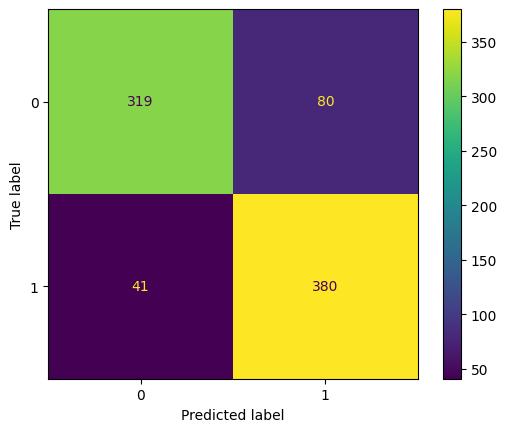

In [13]:
# Training Confusion Matrix
y_train_pred = model.predict(X_train)
train_cm = confusion_matrix(Y_train , y_train_pred)
print('Training Confusion Matrix:\n' , train_cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix = train_cm)
disp.plot()

Test Confusion Matrix:
 [[72 28]
 [12 93]]


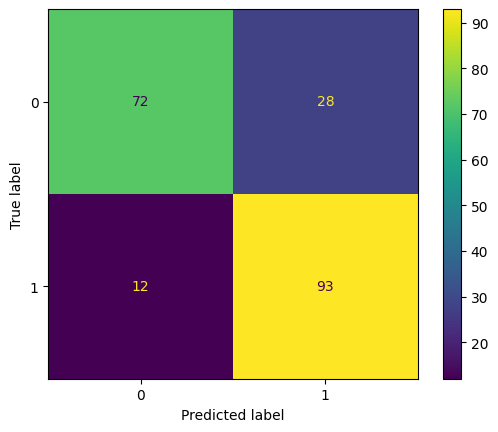

In [14]:
# Test Confusion Matrix
y_test_pred = model.predict(X_test)
test_cm = confusion_matrix(Y_test ,y_test_pred)
print('Test Confusion Matrix:\n' , test_cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix = test_cm)
disp.plot()

**Accuracy**

In [15]:
# Accuracy on Training Data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction , Y_train)
print('Accuracy on Training data :' , training_data_accuracy)

Accuracy on Training data : 0.8524390243902439


In [16]:
# Accuracy on Test Data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction , Y_test)
print('Accuracy on Test Data :' , test_data_accuracy)

Accuracy on Test Data : 0.8048780487804879


**Precision**

In [17]:
# Training Precision
y_train_pred = model.predict(X_train)
train_precision = precision_score(Y_train, y_train_pred)
print('Training Precision :' , train_precision)

Training Precision : 0.8260869565217391


In [18]:
# Test Precision
y_test_pred = model.predict(X_test)
test_precision = precision_score(Y_test, y_test_pred)
print('Test Precision :', test_precision)

Test Precision : 0.768595041322314


**Recall**

In [19]:
# Training Recall
train_recall = recall_score(Y_train, y_train_pred)
print('Training Recall :', train_recall)

Training Recall : 0.9026128266033254


In [20]:
# Test Recall
test_recall = recall_score(Y_test , y_test_pred)
print('Test Recall :', test_recall)

Test Recall : 0.8857142857142857


**F1 - Score**

In [21]:
# Training F1 Score
train_f1 = f1_score(Y_train , y_train_pred)
print('Training F1 Score :', train_f1)

Training F1 Score : 0.8626560726447219


In [22]:
# Test F1 Score
test_f1 = f1_score(Y_test , y_test_pred)
print('Test F1 Score :', test_f1)

Test F1 Score : 0.8230088495575221


**K-NEAREST NEIGHBORS (KNN)**

In [23]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train , Y_train)

KNeighborsClassifier()

**Model Evaluation**

**Confusion Matrix**

KNN - Training Confusion Matrix:
 [[367  32]
 [ 45 376]]


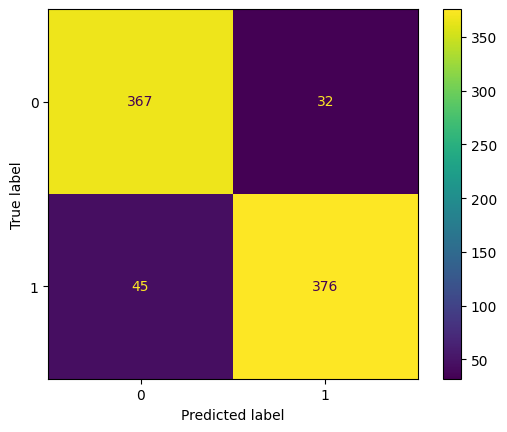

In [24]:
# Training Confusion Matrix
knn_train_pred = knn_model.predict(X_train)
knn_train_cm = confusion_matrix(Y_train , knn_train_pred)
print('KNN - Training Confusion Matrix:\n' , knn_train_cm)

# Display Confusion Matrix
ConfusionMatrixDisplay(knn_train_cm).plot()

KNN - Test Confusion Matrix:
 [[74 26]
 [31 74]]


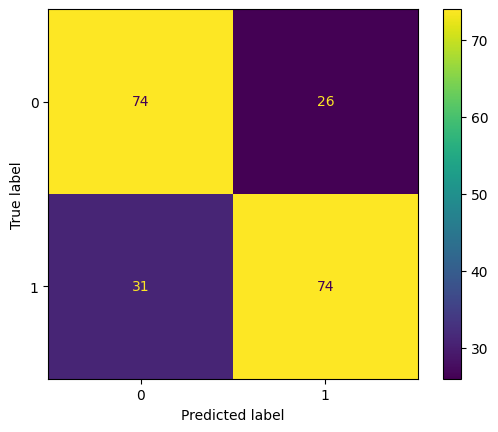

In [25]:
# Test Confusion Matrix
knn_test_pred = knn_model.predict(X_test)
knn_test_cm = confusion_matrix(Y_test , knn_test_pred)
print('KNN - Test Confusion Matrix:\n' , knn_test_cm)

# Display Confusion Matrix
ConfusionMatrixDisplay(knn_test_cm).plot()

**Accuracy**

In [26]:
# Accuracy on Training Data
knn_train_prediction = knn_model.predict(X_train)
knn_training_data_accuracy = accuracy_score(knn_train_prediction , Y_train)
print('Accuracy on Training Data:' , knn_training_data_accuracy)

Accuracy on Training Data: 0.9060975609756098


In [27]:
# Accuracy on Test Data
knn_test_prediction = knn_model.predict(X_test)
knn_test_data_accuracy = accuracy_score(knn_test_prediction , Y_test)
print('Accuracy on Test Data:' , knn_test_data_accuracy)

Accuracy on Test Data: 0.7219512195121951


**Precision**

In [28]:
# Training Precision
knn_y_train_pred = knn_model.predict(X_train)
knn_train_precision = precision_score(Y_train, knn_y_train_pred)
print('Training Precision:', knn_train_precision)

Training Precision: 0.9215686274509803


In [29]:
# Test Precision
knn_y_test_pred = knn_model.predict(X_test)
knn_test_precision = precision_score(Y_test, knn_y_test_pred)
print('Test Precision:', knn_test_precision)

Test Precision: 0.74


**Recall**

In [30]:
# Training Recall
knn_train_recall = recall_score(Y_train , knn_y_train_pred)
print('Training Recall:' , knn_train_recall)

Training Recall: 0.8931116389548693


In [31]:
# Test Recall
knn_test_recall = recall_score(Y_test , knn_y_test_pred)
print('Test Recall:' , knn_test_recall)

Test Recall: 0.7047619047619048


**F1 Score**

In [32]:
# Training F1 Score
knn_train_f1 = f1_score(Y_train , knn_y_train_pred)
print('Training F1 Score:' , knn_train_f1)

Training F1 Score: 0.9071170084439083


In [33]:
# Test F1 Score
knn_test_f1 = f1_score(Y_test , knn_y_test_pred)
print('Test F1 Score:' , knn_test_f1)

Test F1 Score: 0.7219512195121951


**DECISION TREES**

In [34]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)
dt_model.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=4, min_samples_split=10,
                       random_state=42)

**Model Evaluation**

**Confusion Matrix**

Decision Tree - Training Confusion Matrix:
 [[334  65]
 [ 39 382]]


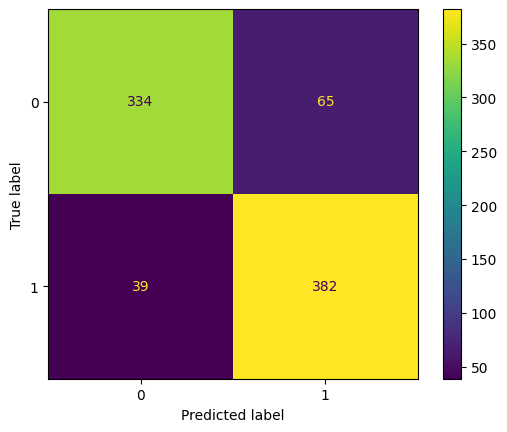

In [35]:
# Training Confusion Matrix
dt_train_pred = dt_model.predict(X_train)
dt_train_cm = confusion_matrix(Y_train, dt_train_pred)
print('Decision Tree - Training Confusion Matrix:\n', dt_train_cm)

# Display Confusion Matrix
ConfusionMatrixDisplay(dt_train_cm).plot()

Decision Tree - Test Confusion Matrix:
 [[83 17]
 [12 93]]


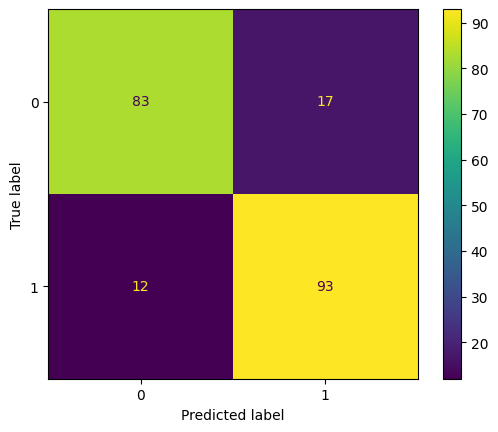

In [36]:
# Test Confusion Matrix
dt_test_pred = dt_model.predict(X_test)
dt_test_cm = confusion_matrix(Y_test , dt_test_pred)
print('Decision Tree - Test Confusion Matrix:\n' , dt_test_cm)

# Display Confusion Matrix
ConfusionMatrixDisplay(dt_test_cm).plot()

**Accuracy**

In [37]:
# Training Accuracy
dt_train_prediction = dt_model.predict(X_train)
dt_training_data_accuracy = accuracy_score(dt_train_prediction , Y_train)
print('Accuracy on Training Data:' , dt_training_data_accuracy)

Accuracy on Training Data: 0.8731707317073171


In [38]:
# Test Accuracy
dt_test_prediction = dt_model.predict(X_test)
dt_test_data_accuracy = accuracy_score(dt_test_prediction , Y_test)
print('Accuracy on Test Data:' , dt_test_data_accuracy)

Accuracy on Test Data: 0.8585365853658536


**Precision**

In [39]:
# Training Precision
dt_y_train_pred = dt_model.predict(X_train)
dt_train_precision = precision_score(Y_train, dt_y_train_pred)
print('Training Precision:', dt_train_precision)

Training Precision: 0.854586129753915


In [40]:
# Test Precision
dt_y_test_pred = dt_model.predict(X_test)
dt_test_precision = precision_score(Y_test, dt_y_test_pred)
print('Test Precision:', dt_test_precision)

Test Precision: 0.8454545454545455


**Recall**

In [41]:
# Training Recall
dt_train_recall = recall_score(Y_train , dt_y_train_pred)
print('Training Recall:' , dt_train_recall)

Training Recall: 0.9073634204275535


In [42]:
# Test Recall
dt_test_recall = recall_score(Y_test , dt_y_test_pred)
print('Test Recall:' , dt_test_recall)

Test Recall: 0.8857142857142857


**F1 Score**

In [43]:
# Training F1 Score
dt_train_f1 = f1_score(Y_train , dt_y_train_pred)
print('Training F1 Score:' , dt_train_f1)

Training F1 Score: 0.880184331797235


In [44]:
# Test F1 Score
dt_test_f1 = f1_score(Y_test , dt_y_test_pred)
print('Test F1 Score:' , dt_test_f1)

Test F1 Score: 0.8651162790697674


**RANDOM FOREST**

In [45]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)
rf_model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=300, random_state=42)

**Model Evaluation**

**Confusion Matrix**

Random Forest - Training Confusion Matrix:
 [[360  39]
 [ 13 408]]


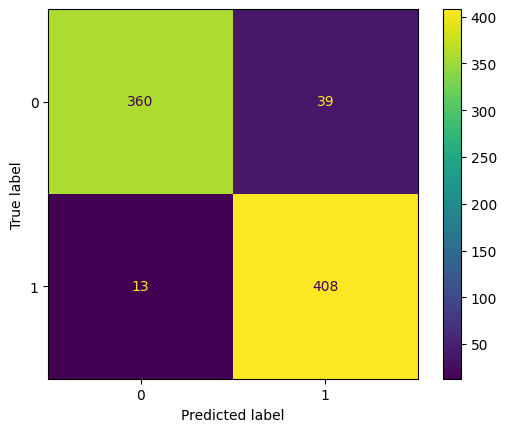

In [46]:
# Training Confusion Matrix
rf_train_pred = rf_model.predict(X_train)
rf_train_cm = confusion_matrix(Y_train, rf_train_pred)
print("Random Forest - Training Confusion Matrix:\n", rf_train_cm)

# Display Confusion Matrix
ConfusionMatrixDisplay(rf_train_cm).plot()

Random Forest - Test Confusion Matrix:
 [[89 11]
 [ 6 99]]


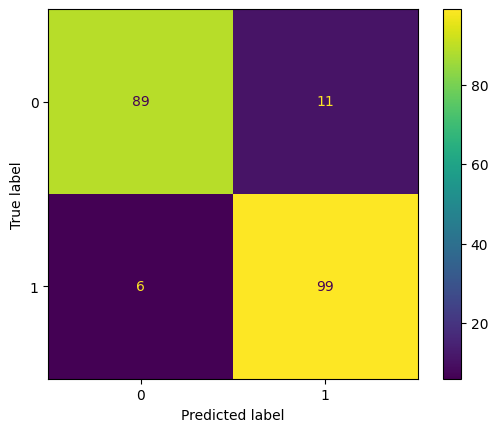

In [47]:
# Test Confusion Matrix
rf_test_pred = rf_model.predict(X_test)
rf_test_cm = confusion_matrix(Y_test, rf_test_pred)
print("Random Forest - Test Confusion Matrix:\n", rf_test_cm)

# Display Confusion Matrix
ConfusionMatrixDisplay(rf_test_cm).plot()

**Accuracy**

In [48]:
# Accuracy on Training Data
rf_train_prediction = rf_model.predict(X_train)
rf_training_data_accuracy = accuracy_score(rf_train_prediction , Y_train)
print('Accuracy on Training data :', rf_training_data_accuracy)

Accuracy on Training data : 0.9365853658536586


In [49]:
# Accuracy on Test Data
rf_test_prediction = rf_model.predict(X_test)
rf_test_data_accuracy = accuracy_score(rf_test_prediction , Y_test)
print('Accuracy on Test Data :' , rf_test_data_accuracy)

Accuracy on Test Data : 0.9170731707317074


**Precision**

In [50]:
# Training Precision
rf_y_train_pred = rf_model.predict(X_train)
rf_train_precision = precision_score(Y_train, rf_y_train_pred)
print('Training Precision :' , rf_train_precision)

Training Precision : 0.912751677852349


In [51]:
# Test Precision
rf_y_test_pred = rf_model.predict(X_test)
rf_test_precision = precision_score(Y_test, rf_y_test_pred)
print('Test Precision :' , rf_test_precision)

Test Precision : 0.9


**Recall**

In [52]:
# Training Recall
rf_train_recall = recall_score(Y_train, rf_y_train_pred)
print('Training Recall :' , rf_train_recall)

Training Recall : 0.9691211401425178


In [53]:
# Test Recall
rf_test_recall = recall_score(Y_test , rf_y_test_pred)
print('Test Recall :' , rf_test_recall)

Test Recall : 0.9428571428571428


**F1 Score**

In [54]:
# Training F1 Score
rf_train_f1 = f1_score(Y_train , rf_y_train_pred)
print('Training F1 Score :' , rf_train_f1)

Training F1 Score : 0.9400921658986175


In [55]:
# Test F1 Score
rf_test_f1 = f1_score(Y_test , rf_y_test_pred)
print('Test F1 Score :' , rf_test_f1)

Test F1 Score : 0.9209302325581395


**SUPPORT VECTOR MACHINES (SVM)**

In [56]:
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, Y_train)

SVC()

**Model Evaluation**

**Confusion Matrix**

RBF SVM - Training Confusion Matrix:
 [[264 135]
 [ 94 327]]


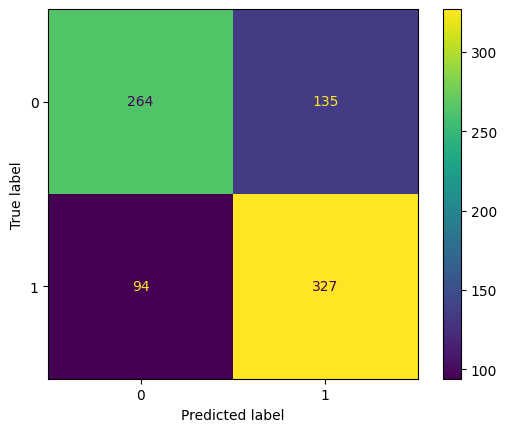

In [57]:
# Training Confusion Matrix
svm_r_train_pred = svm_rbf.predict(X_train)
svm_r_train_cm = confusion_matrix(Y_train, svm_r_train_pred)
print("RBF SVM - Training Confusion Matrix:\n", svm_r_train_cm)

# Display Confusion Matrix
ConfusionMatrixDisplay(svm_r_train_cm).plot()

RBF SVM - Test Confusion Matrix:
 [[63 37]
 [23 82]]


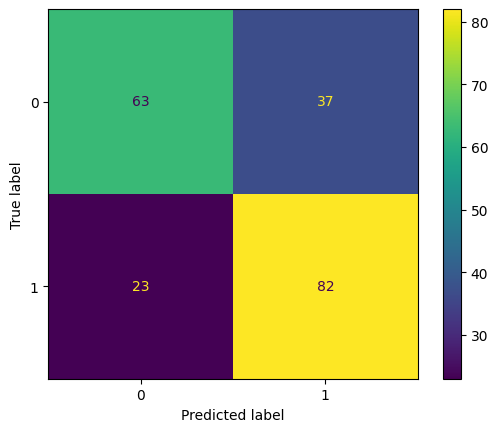

In [58]:
# Test Confusion Matrix
svm_r_test_pred = svm_rbf.predict(X_test)
svm_r_test_cm = confusion_matrix(Y_test, svm_r_test_pred)
print("RBF SVM - Test Confusion Matrix:\n", svm_r_test_cm)

# Display Confusion Matrix
ConfusionMatrixDisplay(svm_r_test_cm).plot()

**Accuracy**

In [59]:
# Accuracy on Training Data
svm_train_prediction = svm_rbf.predict(X_train)
svm_training_data_accuracy = accuracy_score(svm_train_prediction , Y_train)
print('Accuracy on Training Data:' , svm_training_data_accuracy)

Accuracy on Training Data: 0.7207317073170731


In [60]:
# Accuracy on Test Data
svm_test_prediction = svm_rbf.predict(X_test)
svm_test_data_accuracy = accuracy_score(svm_test_prediction , Y_test)
print('Accuracy on Test Data:' , svm_test_data_accuracy)

Accuracy on Test Data: 0.7073170731707317


**Precision**

In [61]:
# Training Precision
svm_train_precision = precision_score(Y_train , svm_r_train_pred)
print('Training Precision:' , svm_train_precision)

Training Precision: 0.7077922077922078


In [62]:
# Test Precision
svm_test_precision = precision_score(Y_test , svm_r_test_pred)
print('Test Precision:' , svm_test_precision)

Test Precision: 0.6890756302521008


**Recall**

In [63]:
# Training Recall
svm_train_recall = recall_score(Y_train , svm_r_train_pred)
print('Training Recall:' , svm_train_recall)

Training Recall: 0.7767220902612827


In [64]:
# Test Recall
svm_test_recall = recall_score(Y_test , svm_r_test_pred)
print('Test Recall:' , svm_test_recall)

Test Recall: 0.780952380952381


**F1 Score**

In [65]:
# Training F1 Score
svm_train_f1 = f1_score(Y_train , svm_r_train_pred)
print('Training F1 Score:' , svm_train_f1)

Training F1 Score: 0.7406568516421291


In [66]:
# Test F1 Score
svm_test_f1 = f1_score(Y_test , svm_r_test_pred)
print('Test F1 Score:' , svm_test_f1)

Test F1 Score: 0.7321428571428571


**XGBOOST**

In [67]:
xgb_model = XGBClassifier(
    max_depth=3,
    n_estimators=200,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=3,
    random_state=2
)
xgb_model.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

**Model Evaluation**

**Confusion Matrix**

Training Confusion Matrix:
 XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)


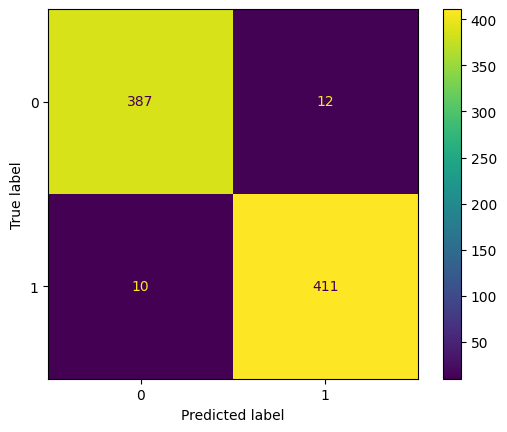

In [68]:
# Training Confusion Matrix
xgb_y_train_pred = xgb_model.predict(X_train)
xgb_train_cm = confusion_matrix(Y_train , xgb_y_train_pred)
print('Training Confusion Matrix:\n' , xgb_model)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix = xgb_train_cm)
disp.plot()

Test Confusion Matrix:
 XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)


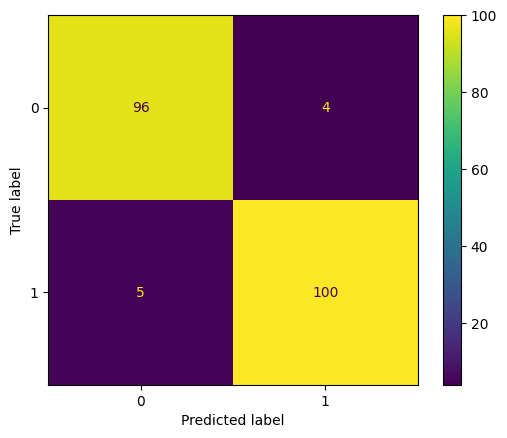

In [69]:
# Test Confusion Matrix
xgb_y_test_pred = xgb_model.predict(X_test)
xgb_test_cm = confusion_matrix(Y_test , xgb_y_test_pred)
print('Test Confusion Matrix:\n' , xgb_model)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix = xgb_test_cm)
disp.plot()

**Accuracy**

In [70]:
# Accuracy on Training Data
xgb_train_prediction = xgb_model.predict(X_train)
xgb_train_data_accuracy = accuracy_score(xgb_train_prediction , Y_train)
print('Accuracy on Training data:' , xgb_train_data_accuracy)

Accuracy on Training data: 0.973170731707317


In [71]:
# Accuracy on Test Data
xgb_test_prediction = xgb_model.predict(X_test)
xgb_test_data_accuracy = accuracy_score(xgb_test_prediction , Y_test)
print('Accuracy on Training data:' , xgb_test_data_accuracy)

Accuracy on Training data: 0.9560975609756097


**Precision**

In [72]:
# Training Precision
xgb_train_precision = precision_score(Y_train , xgb_y_train_pred)
print('Training Precision:' , xgb_train_precision)

Training Precision: 0.9716312056737588


In [73]:
# Test Precision
xgb_test_precision = precision_score(Y_test , xgb_y_test_pred)
print('Test Precision:' , xgb_test_precision)

Test Precision: 0.9615384615384616


**Recall**

In [74]:
# Training Recall
xgb_train_recall = recall_score(Y_train , xgb_y_train_pred)
print('Training Recall:' , xgb_train_recall)

Training Recall: 0.9762470308788599


In [75]:
# Test Recall
xgb_test_recall = recall_score(Y_test , xgb_y_test_pred)
print('Test Recall:' , xgb_test_recall)

Test Recall: 0.9523809523809523


**F1 Score**

In [76]:
# Training F1 Score
xgb_train_f1 = f1_score(Y_train , xgb_y_train_pred)
print('Training F1 Score:' , xgb_train_f1)

Training F1 Score: 0.9739336492890995


In [77]:
# Test F1 Score
xgb_test_f1 = f1_score(Y_test , xgb_y_test_pred)
print('Test F1 Score:' , xgb_test_f1)

Test F1 Score: 0.9569377990430622


**ARTIFICIAL NEURAL NETWORKS (ANN)**

**Scale Data**

In [78]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Build the ANN**

In [79]:
ann_model = Sequential()
ann_model.add(Input(shape=(X_train_scaled.shape[1],)))
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dropout(0.2))
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))  # Binary classification

**Compile the ANN**

In [80]:
ann_model.compile(optimizer = 'adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'])

**Train the ANN**

In [81]:
history = ann_model.fit(X_train_scaled , Y_train , epochs = 100 , batch_size = 16 , validation_split = 0.2 , verbose = 0)

**Evaluation Metrics**

**Confusion Matrix**

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Training Confusion Matrix:
 [[399   0]
 [418   3]]


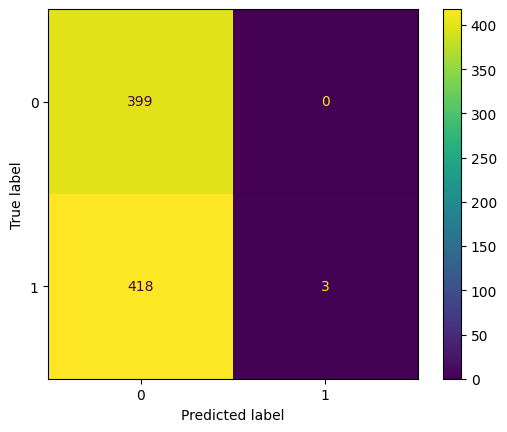

In [82]:
# Training Confusion Matrix
ann_train_prediction = ann_model.predict(X_train)
ann_train_prediction = (ann_train_prediction > 0.5).astype(int)
ann_y_train_pred = ann_train_prediction
ann_train_cm = confusion_matrix(Y_train , ann_y_train_pred)
print('Training Confusion Matrix:\n' , ann_train_cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix = ann_train_cm)
disp.plot();

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Test Confusion Matrix:
 [[100   0]
 [105   0]]


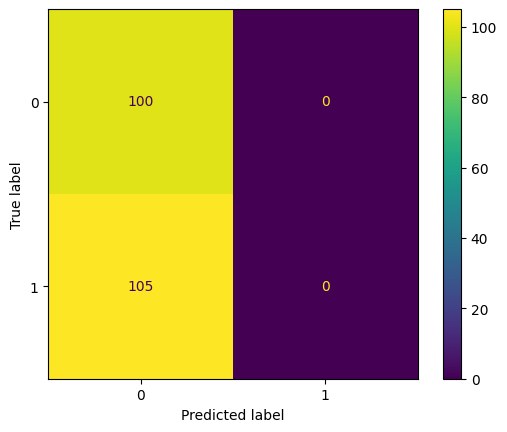

In [83]:
# Test Confusion Matrix
ann_test_prediction = ann_model.predict(X_test)
ann_test_prediction = (ann_test_prediction > 0.5).astype(int)
ann_y_test_pred = ann_test_prediction
ann_test_cm = confusion_matrix(Y_test , ann_y_test_pred)
print('Test Confusion Matrix:\n' , ann_test_cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix = ann_test_cm)
disp.plot();

**Accuracy**

In [84]:
# Accuracy on Training Data
ann_train_prediction = (ann_model.predict(X_train_scaled) > 0.5).astype("int32")
ann_training_data_accuracy = accuracy_score(Y_train ,ann_train_prediction)
print('Accuracy on Training Data:' , ann_training_data_accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy on Training Data: 0.9817073170731707


In [85]:
# Accuracy on Test Data
ann_test_prediction = (ann_model.predict(X_test_scaled) > 0.5).astype("int32")
ann_test_data_accuracy = accuracy_score(Y_test ,ann_test_prediction)
print('Accuracy on Test Data:' , ann_test_data_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy on Test Data: 0.9512195121951219


**Precision**

In [86]:
# Training Precision
ann_train_precision = precision_score(Y_train , y_train_pred)
print('Training Precision:' , ann_train_precision)

Training Precision: 0.8260869565217391


In [87]:
# Test Precision
ann_test_precision = precision_score(Y_test , y_test_pred)
print('Test Precision:' , ann_test_precision)

Test Precision: 0.768595041322314


**Recall**

In [88]:
# Training Recall
ann_train_recall = recall_score(Y_train , y_train_pred)
print('Training Recall:' , ann_train_recall)

Training Recall: 0.9026128266033254


In [89]:
# Test Recall
ann_test_recall = recall_score(Y_test , y_test_pred)
print('Test Recall:' , ann_test_recall)

Test Recall: 0.8857142857142857


**F1 Score**

In [90]:
# Training F1 Score
ann_train_f1 = f1_score(Y_train , y_train_pred)
print('Training F1:' , ann_train_f1)

Training F1: 0.8626560726447219


In [91]:
# Test F1 Score
ann_test_f1 = f1_score(Y_test , y_test_pred)
print('Test F1:' , ann_test_f1)

Test F1: 0.8230088495575221


**Building a Predictive System**

In [92]:
feature_names = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
                 'exang','oldpeak','slope','ca','thal']
input_data = (64,0,2,140,313,0,1,133,0,0.2,2,0,3)

# Convert to DataFrame
input_df = pd.DataFrame([input_data], columns=feature_names)

# Prediction
prediction = model.predict(input_df)
print(prediction)

if prediction[0] == 0:
    print('The Person does not have Heart Disease')
else:
    print('The Person has Heart Disease')

# Probability prediction
prob = model.predict_proba(input_df)
print("Probability of Heart Disease:", prob[0][1])
print("Probability of No Heart Disease:", prob[0][0])

[1]
The Person has Heart Disease
Probability of Heart Disease: 0.8851495540437514
Probability of No Heart Disease: 0.1148504459562486
